In [14]:
#load the required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
# Step 1: Load the data from CSV
file_name = "Linear_regression_dataset.csv"
df = pd.read_csv(file_name)


In [16]:
# Step 2: Separate features (X) and target (y)
# Assume the last column is the target; adjust accordingly if that's not the case
X = df.iloc[:, :-1]  # All columns except the last one
y = df.iloc[:, -1]   # The last column

In [17]:
# Step 3: Scale the features
scaler = MinMaxScaler()
#scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [19]:
# Step 5: Define the ANN model
model = Sequential([
    Dense(10, input_dim=X_train.shape[1], activation='relu'),  # First hidden layer
    Dense(8, activation='relu'),                               # Second hidden layer
    Dense(1, activation='linear')                              # Output layer
])

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# Step 6: Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [21]:
# Step 7: Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_split=0.1, verbose=0)

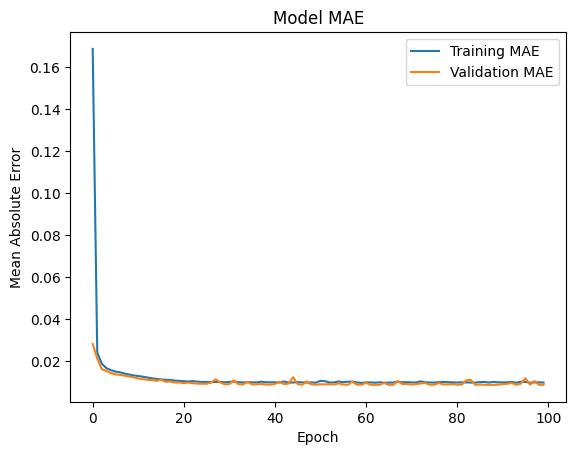

In [22]:
import matplotlib.pyplot as plt

# Plot MAE
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

In [23]:
# Step 8: Evaluate the model
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {loss}")
print(f"Mean Absolute Error: {mae}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.5847e-04 - mae: 0.0100 
Test Loss: 0.0001584699930390343
Mean Absolute Error: 0.010015732608735561


In [24]:
# Step 10: Calculate additional metrics
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)  # Root Mean Squared Error
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.01
R-squared (R²): 0.87


In [25]:
#Display Linear Regression graph
import matplotlib.pyplot as plt

# Step 9: Make predictions
#print("Predictions:", predictions)

#Display Actual Vs Predicted
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions.flatten() #If predictions are (n,1) and y_test is (n,), use predictions.flatten().
})

results.head(5)

,Actual,Predicted
0,0.342,0.353234
1,0.436,0.419029
2,0.472,0.473268
3,0.381,0.385328
4,0.327,0.333206


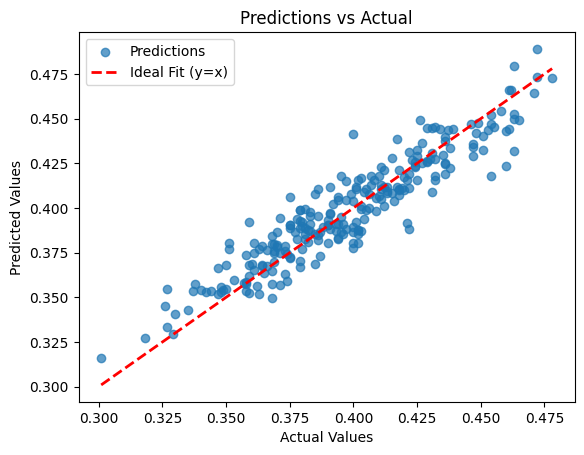

In [26]:
import numpy as np

plt.scatter(y_test, predictions, alpha=0.7, label="Predictions")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label="Ideal Fit (y=x)") # r-- means red with --
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predictions vs Actual")
plt.legend()
plt.show()

! Well Done